# Explore here

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [70]:
# Your code here
import kagglehub
import shutil
import os
import pandas as pd

#Descargar la última versión del dataset
path = kagglehub.dataset_download("kylefengkfeng209/screen-time-vs-mental-health-ml-ready")

#Copiar el archivo CSV a tu carpeta de trabajo actual en VS Code
csv_filename = "screen_time_mental_health.csv"
source_file = os.path.join(path, csv_filename)
destination_file = os.path.join(os.getcwd(), csv_filename)

shutil.copy(source_file, destination_file)

'/Users/javiaburto/Documents/GitHub/prueba_para_proyecto/src/screen_time_mental_health.csv'

In [71]:
df = pd.read_csv("../data/raw/screen_time_mental_health.csv")
df

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0
...,...,...,...,...,...,...,...,...,...,...
4805,4806,Girl,2.333,2.07,1.50,8.76,4.08,2.00,20,1
4806,4807,Boy,4.333,6.07,1.00,6.60,7.46,3.46,6,0
4807,4808,Girl,2.333,2.07,1.25,6.61,5.25,1.62,1,0
4808,4809,Girl,3.667,4.64,1.25,7.15,5.54,2.83,0,0


In [72]:
df.shape

(4810, 10)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 392.3 KB


In [74]:
df.columns

Index(['subject_id', 'sex', 'screen_time_index', 'est_leisure_screen_hours',
       'sleep_quality_index', 'avg_sleep_hours', 'midsleep_weekend_hours',
       'social_jetlag_hours', 'bdi_total', 'depressed'],
      dtype='str')

In [75]:
df['sex'] = pd.factorize(df['sex'])[0]
    
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   int64  
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(4)
memory usage: 375.9 KB


In [76]:
df.drop(['subject_id'],axis=1,inplace=True)

df.head()

,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,0,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,1,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,0,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,0,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,0,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [77]:
X = df.drop(columns=['depressed'])
y= df['depressed']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [78]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_escalados = scaler.fit_transform(X_train)

X_train_escalados = pd.DataFrame(X_train_escalados, columns= X_train.columns, index = X_train.index)

X_test_escalados = scaler.transform(X_test)

X_test_escalados = pd.DataFrame(X_test_escalados, columns= X_test.columns, index = X_test.index)

X_train_escalados

,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total
402,1.0,0.5334,0.526316,0.05,0.706897,0.403171,0.538693,0.078431
4544,0.0,0.1334,0.074737,0.20,0.618774,0.272933,0.459296,0.137255
2856,0.0,0.3334,0.165263,0.00,0.723180,0.240091,0.428141,0.078431
3047,0.0,0.2666,0.165263,0.05,0.573755,0.556059,0.654271,0.019608
4585,0.0,0.8000,1.000000,0.00,0.684866,0.749717,0.731658,0.137255
...,...,...,...,...,...,...,...,...
4426,1.0,0.2000,0.105263,0.20,0.521073,0.390713,0.467337,0.764706
466,1.0,0.6666,0.662105,0.20,0.545019,0.533409,0.580905,0.215686
3092,1.0,0.6000,0.586316,0.10,0.636973,0.509626,0.694472,0.039216
3772,0.0,0.8666,0.811579,0.40,0.482759,0.240091,0.342714,0.215686


In [86]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_escalados, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [87]:
import numpy as np 

y_pred = model.predict(X_test_escalados)

y_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [88]:
from sklearn.metrics import accuracy_score, f1_score

print(accuracy_score(y_test, y_pred))

print(f1_score(y_test, y_pred))

1.0
1.0


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       1.00      1.00      1.00       146

    accuracy                           1.00       962
   macro avg       1.00      1.00      1.00       962
weighted avg       1.00      1.00      1.00       962



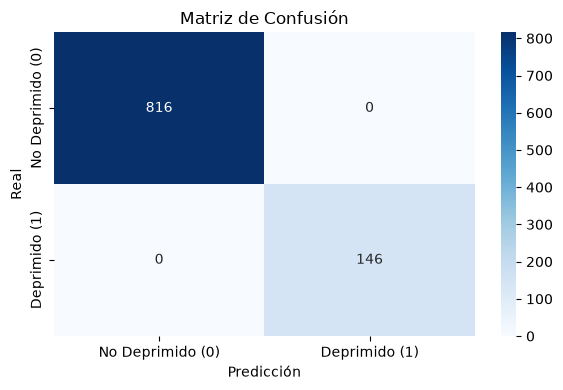

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Reporte de Clasificación en texto
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 2. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización gráfica de la matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Deprimido (0)', 'Deprimido (1)'], 
            yticklabels=['No Deprimido (0)', 'Deprimido (1)'])

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()
